## Setting Up the Libs and Marmousi2 Configurations

In [1]:
##### from __future__ import print_function
import time
import torch
import torch.nn as nn
import numpy as np
import scipy.ndimage
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import deepwave
import os
from timeit import default_timer as timer
import scipy.io as spio
import math
import numpy as np
from utils.utils import *
from torch import optim
from IPython.core.debugger import set_trace 
import random
torch.manual_seed(0)
random.seed(0)

####################################################
####   MAIN PARAMETERS FOR FORWARD MODELING         ####
####################################################

peak_freq = 5.                    # central frequency
peak_source_time = 1 / peak_freq  # the time (in secs) of the peak amplitude
dx        = 30.0                  # step interval along x/z direction
dt        = 0.003                 # time interval (e.g., 3ms)
num_dims  = 2                     # dimension of velocity model
nz        = 117                   # model shape of z dimension (depth) Marmousi2
ny        = 567                   # model shape of y dimension Marmousi2
vmodel_dim = np.array([nz, ny])

total_t   = 6.                      # totle sampling time (unit: s)
nt        = int(total_t / dt)       # number of time sampling points
num_shots = 6                      # nunmber of shots
num_sources_per_shot = 5            # number of sources per 
num_shotsall = num_shots * num_sources_per_shot
num_receivers_per_shot = 567        # number of receivers per shot
source_spacing = np.floor(dx * ny / (num_shotsall+1))                         # space intervel between neigbouring sources
receiver_spacing = np.floor(dx * ny / (num_receivers_per_shot +1))         # space intervel between neigbouring receivers
source_depth = 0                # the index depth of sources, default is 0
receiver_depth = 0              # the index depths of receivers, default is 0
order          = 8              # precision order of finite difference in space domain
pml_width  = [0,10,10,10,0,0]   # pml padding width for boundary (0 for free surface and 10 for absorbing boundary)

fwi_lr = 30
fwi_batch         =   num_shots      # number of batches for FWI.
fwi_num_epochs    = 200       # number of FWI iteration.
sim_lr = 1e-8
survey_pad = None
savepoch = 50                 # Saving models each 50 FWI iterations


/home/sadalyom/.conda/envs/FWIGAN/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##   Check Cuda Device 


In [2]:
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

cuda_available = torch.cuda.is_available()
device = torch.device("cuda" if cuda_available else "cpu")
device

device(type='cuda')

## Sorting the sources randomly


In [3]:

''' 
indx = []
for i in range (num_shots):
    indx.append(np.arange(i,num_shotsall,num_shots))
indx = (np.array(indx)).flatten()
'''
np.random.seed(42)
indx = np.random.permutation(num_shotsall)

indx

array([27, 15, 23, 17,  8,  9, 28, 24, 12,  0,  4, 16,  5, 13, 11, 22,  1,
        2, 25,  3, 21, 26, 18, 29, 20,  7, 10, 14, 19,  6])

In [4]:
 
data_path = 'data/mar_big_117_567.bin'
initfile = 'data/mar_big_initmodel.mat'
initsafile = 'data/mar_big_initsource.mat'
fwi_result = 'results/marmousi2_SiameseFit_MultiSource_16FM/'

# Check if the directory exists
if not os.path.exists(fwi_result):
    # Create the directory
    os.makedirs(fwi_result)
    print(f"Directory '{fwi_result}' created.")
else:
    print(f"Directory '{fwi_result}' already exists.")
    
# Loading the true model
model_true = loadtruemodel(data_path, num_dims, vmodel_dim).to(device)
# Smooth initial model
model, model_init = createInitialModel(model_true, 'GS', 10, 0, device)


# The model will be updated during FWI
model = torch.nn.Parameter(model)
# Creating source and reciver locations
_, x_r = createSR(num_shots, num_sources_per_shot, num_receivers_per_shot, num_dims, source_spacing, receiver_spacing,source_depth,receiver_depth)
x_s, _ = createSR(num_shotsall, 1, num_receivers_per_shot, num_dims, source_spacing, receiver_spacing,source_depth,receiver_depth)
x_s = x_s[indx]
x_s = x_s.reshape(num_shots, num_sources_per_shot,2)
x_s, x_r = x_s.to(device), x_r.to(device)
# Source Amplitude
source_amplitudes_init, source_amplitudes_true = loadinitsource(initsafile,device)
source = source_amplitudes_init.repeat(1,num_shots, num_sources_per_shot)
# receiver Amplitude
receiver_amplitudes = createdata(model_true,dx,source, \
                                x_s,x_r,dt,pml_width,order, \
                                 survey_pad,device).to(device)
receiver_amplitudes_true = receiver_amplitudes
rcv_amps_true = receiver_amplitudes_true.clone()

Directory 'results/marmousi2_SiameseFit_MultiSource_16FM/' already exists.
model size: torch.Size([117, 567])


In [5]:
x_r.shape, x_s.shape, x_r[0].shape, source.shape

(torch.Size([6, 567, 2]),
 torch.Size([6, 5, 2]),
 torch.Size([567, 2]),
 torch.Size([2000, 6, 5]))

## Plotting the inital and true model


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


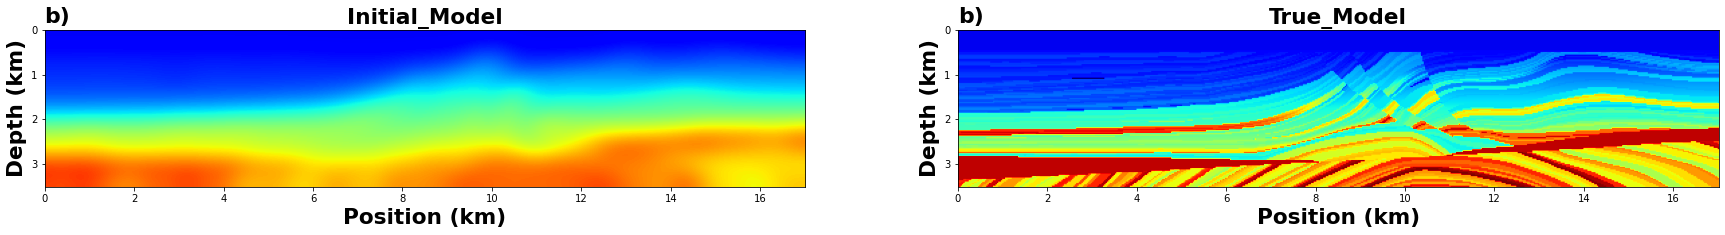

In [6]:
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 18}

y = np.array([0, 1, 2, 3, 4])
box_min = 1140
box_max = 4700

f, ax = plt.subplots(1,2,figsize=(30, 13))
plt.rc('font', **font)


im = ax[0].imshow(model_init, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, model_init.shape[1] * dx / 1000, model_init.shape[0] * dx / 1000, 0])
ax[0].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[0].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[0].set_title('Initial_Model',fontsize='large', fontweight='bold')
ax[0].text(0, -0.15, 'b)', fontsize = 22) 
ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[0].set_yticks(np.arange(y.min(), y.max(), 1)) 

model1 = model_true.detach().cpu().numpy()
im = ax[1].imshow(model1, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, model1.shape[1] * dx / 1000, model1.shape[0] * dx / 1000, 0])
ax[1].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[1].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[1].set_title('True_Model',fontsize='large', fontweight='bold')
ax[1].text(0, -0.15, 'b)', fontsize = 22) 
ax[1].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[1].set_yticks(np.arange(y.min(), y.max(), 1)) 


plt.show()

## Setting Up the Siamese and Optimizers

In [7]:
from torchsummary import summary
from Model.Module22xP_1 import *
import  torch


#Learning Schedule
def lr_lambda(epoch):
    return 10

#Learning Schedule
def lr_lambdaM(epoch):
    return 1/2

### optimizer for the velocity model
optimizer = optim.Adam([{'params': model, 'lr':fwi_lr, 'betas':(0.5, 0.99), 'eps':1e-22,
                          'weight_decay':0}])

#Best
#leak_value = 0.0001
leak_value = 1
D1 = 16
netD = SiameseNetwork(D1)
### init the hyper-parameters of netD ###
netD = netD.apply(lambda m: weights_init(m, leak_value))
netD = netD.to(device)


# Optimizer for Siamese network.
optim_s = optim.Adam(netD.parameters(),lr=sim_lr,betas=(0.5, 0.9), \
                    eps=1e-8, weight_decay=0)

scheduler = torch.optim.lr_scheduler.MultiplicativeLR(optim_s, lr_lambda=lr_lambda)
schedulerM = torch.optim.lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lr_lambdaM)

"""Compute number of parameters"""
s  = sum(np.prod(list(p.size())) for p in netD.parameters())
print ('Number of netD params: %d' % s)

summary(netD,[(1,nt,num_receivers_per_shot)])


############## Init  ################# 
SNR = 0.0
SSIM = 0.0
Loss = 0.0
ERROR = 0.0




Number of netD params: 100705
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1        [-1, 16, 2000, 567]             160
         LeakyReLU-2        [-1, 16, 2000, 567]               0
            Conv2d-3        [-1, 32, 2000, 567]             320
         LeakyReLU-4        [-1, 32, 2000, 567]               0
            Conv2d-5        [-1, 64, 2000, 567]             640
         LeakyReLU-6        [-1, 64, 2000, 567]               0
            Conv2d-7       [-1, 128, 2000, 567]           1,280
         LeakyReLU-8       [-1, 128, 2000, 567]               0
            Conv2d-9        [-1, 16, 2000, 567]             160
        LeakyReLU-10        [-1, 16, 2000, 567]               0
        MaxPool2d-11        [-1, 16, 1000, 283]               0
        MaxPool2d-12        [-1, 16, 1000, 283]               0
           Conv2d-13        [-1, 32, 1000, 283]           4,640
        L

## Main SiameseFWI

In [8]:
import torch.fft
import torch.nn.functional as F
# Starting the FWI loop.
global model_true, source_amplitudes_init, SNR, SSIM, Loss, ERROR






t_start = time.time()
model_true = model_true.view(nz,ny)
# number of shots per batch
num_shots_per_batch = int(num_shots / fwi_batch) 
criterion = nn.MSELoss()
for i in range(fwi_num_epochs):
    # initialization of the loss
    epoch_loss = 0.0

    #batch_rcv_amps_true = torch.zeros((2000,1,567)).to(device)
    #batch_rcv_amps_pred = torch.zeros((2000,1,567)).to(device)
    for it in range(fwi_batch):
        iteration = i*fwi_batch+it+1
        #print(it,iteration)
        # Set both optimizers to zero grad.
        optimizer.zero_grad()
        netD.train()                
        netD.zero_grad() 
        
        # Forward modeling based on AWE (DeepWave).
        prop = deepwave.scalar.Propagator({'vp': model},dx,pml_width, \
                                          order,survey_pad)
        batch_src_amps = source_amplitudes_init.repeat(1, num_shots_per_batch, num_sources_per_shot)
        batch_rcv_amps_true= rcv_amps_true[:,it::fwi_batch].to(device)
        batch_x_s = x_s[it::fwi_batch].to(device)
        batch_x_r = x_r[it::fwi_batch].to(device)
        batch_rcv_amps_pred= prop(batch_src_amps, batch_x_s, batch_x_r, dt)
        
        # Prepare the data for Siamese network.
        d_real = batch_rcv_amps_true.permute(1,0,2)
        d_real = d_real.unsqueeze(1)
        # train with fake data
        d_fake = batch_rcv_amps_pred.permute(1,0,2)
        d_fake = d_fake.unsqueeze(1)
        d_real = d_real/torch.norm(d_real, p=2)
        d_fake = d_fake/torch.norm(d_fake, p=2)
        o1 = netD(d_real)
        o2 = netD(d_fake)
        # Measure the Eculedian Loss.
        loss1 =   F.pairwise_distance(o1, o2, keepdim = True).mean()
        
        observed_l2_norm = torch.norm(o2, p=2)
        loss = loss1/observed_l2_norm


        epoch_loss += loss.item()
        loss.backward()
        # Updating the Siamese network.
        optim_s.step()

        # Clips gradient value of model
        torch.nn.utils.clip_grad_value_(model,1e3) 
        # Update the velocity model
        optimizer.step()
        # clip the model value that keep the minimum value is larger than 0
        model.data=torch.clamp(model.data,min=1e-12)
        with torch.no_grad():
            model.data[0:16,:] = 1500

    # Update the learning rate each 100 FWI iterations .
    # Update the learning rate each 100 FWI iterations .
    if (i>0) and (i%100==0):
        schedulerM.step()
        
    after_lr = optim_s.param_groups[0]["lr"]
    
    Loss = np.append(Loss, epoch_loss / fwi_batch)

    # compute the SNR and SSIM
    snr = ComputeSNR(model.detach().cpu().numpy(),  
              model_true.detach().cpu().numpy())
    SNR = np.append(SNR, snr)

    ssim = ComputeSSIM(model.detach().cpu().numpy(), \
              model_true.detach().cpu().numpy())
    SSIM = np.append(SSIM, ssim)

    
    rerror = ComputeRE(model.detach().cpu().numpy(), \
              model_true.detach().cpu().numpy())
    ERROR = np.append(ERROR, rerror)

    print('Epoch:', i+1, 'Loss: ', epoch_loss / fwi_batch, 'lr:' , str(after_lr), 'SNR:', snr, 'SSIM:', ssim.cpu().detach().cpu().numpy())
    if (i+1) % savepoch == 0 or (i+1) == fwi_num_epochs:
    # Save the model and the metrics.
        spio.savemat(fwi_result+'SIAMESERec_.mat', \
                         {'rec':model.cpu().data.numpy()}) 
        spio.savemat(fwi_result+'SIAMESEMetric_.mat', \
                         {'SNR':SNR,'SSIM':SSIM, \
                          'Loss':Loss,'ERROR':ERROR}) 

# Estimating the FWI time
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))
# Save the final metrics.
np.savetxt(fwi_result+'run_result.txt', np.hstack((fwi_num_epochs,elapsed_time//60,elapsed_time % 60,snr,ssim,rerror)), fmt='%5.4f') 



Epoch: 1 Loss:  0.0035961479103813567 lr: 1e-08 SNR: 17.23308827277126 SSIM: 0.26424158
Epoch: 2 Loss:  0.0024565695396934948 lr: 1e-08 SNR: 17.149605699275824 SSIM: 0.26758453
Epoch: 3 Loss:  0.002055163844488561 lr: 1e-08 SNR: 17.12095671607195 SSIM: 0.2761883
Epoch: 4 Loss:  0.0018857713245476286 lr: 1e-08 SNR: 17.154721396506606 SSIM: 0.28868616
Epoch: 5 Loss:  0.001801269594579935 lr: 1e-08 SNR: 17.181813446591036 SSIM: 0.29904908
Epoch: 6 Loss:  0.0017543592645476262 lr: 1e-08 SNR: 17.21620448357173 SSIM: 0.30725503
Epoch: 7 Loss:  0.0017243164281050365 lr: 1e-08 SNR: 17.25523076321717 SSIM: 0.31782746
Epoch: 8 Loss:  0.0016991445251430075 lr: 1e-08 SNR: 17.268134795906228 SSIM: 0.32296315
Epoch: 9 Loss:  0.001681114799187829 lr: 1e-08 SNR: 17.298869747544032 SSIM: 0.33062607
Epoch: 10 Loss:  0.0016560160244504611 lr: 1e-08 SNR: 17.311896983643443 SSIM: 0.33859885
Epoch: 11 Loss:  0.0016367076702105503 lr: 1e-08 SNR: 17.341984943378897 SSIM: 0.34509525
Epoch: 12 Loss:  0.00162446

Epoch: 94 Loss:  0.0008751482722194245 lr: 1e-08 SNR: 19.39826314424376 SSIM: 0.6070637
Epoch: 95 Loss:  0.0008954641040569792 lr: 1e-08 SNR: 19.39747590216961 SSIM: 0.605127
Epoch: 96 Loss:  0.000863261918614929 lr: 1e-08 SNR: 19.404686097429522 SSIM: 0.6055593
Epoch: 97 Loss:  0.0008525555507124712 lr: 1e-08 SNR: 19.42150497510738 SSIM: 0.6073875
Epoch: 98 Loss:  0.0008737827884033322 lr: 1e-08 SNR: 19.449700923451594 SSIM: 0.6067429
Epoch: 99 Loss:  0.0008523298311047256 lr: 1e-08 SNR: 19.46485760167817 SSIM: 0.60905105
Epoch: 100 Loss:  0.0008469617168884724 lr: 1e-08 SNR: 19.485161303244332 SSIM: 0.6088381
Epoch: 101 Loss:  0.0008714325473799059 lr: 1e-08 SNR: 19.501611953461264 SSIM: 0.6089076
Epoch: 102 Loss:  0.0007747316946430752 lr: 1e-08 SNR: 19.530949450377243 SSIM: 0.62117934
Epoch: 103 Loss:  0.0005086996728399148 lr: 1e-08 SNR: 19.52953652189674 SSIM: 0.63048565
Epoch: 104 Loss:  0.0004978401363284016 lr: 1e-08 SNR: 19.552811522869845 SSIM: 0.63258207
Epoch: 105 Loss:  0

Epoch: 185 Loss:  0.0004551022090405847 lr: 1e-08 SNR: 20.21304041215544 SSIM: 0.68143076
Epoch: 186 Loss:  0.0004514131772642334 lr: 1e-08 SNR: 20.212060857824518 SSIM: 0.68214434
Epoch: 187 Loss:  0.0004449026600923389 lr: 1e-08 SNR: 20.226006059979277 SSIM: 0.6813301
Epoch: 188 Loss:  0.0004512910672929138 lr: 1e-08 SNR: 20.22482709735517 SSIM: 0.6826272
Epoch: 189 Loss:  0.0004500568805572887 lr: 1e-08 SNR: 20.235250240162177 SSIM: 0.68182313
Epoch: 190 Loss:  0.00045194458895518136 lr: 1e-08 SNR: 20.237024837039137 SSIM: 0.68325454
Epoch: 191 Loss:  0.0004581850904893751 lr: 1e-08 SNR: 20.234053267246942 SSIM: 0.6818406
Epoch: 192 Loss:  0.0004521203615392248 lr: 1e-08 SNR: 20.237049341547614 SSIM: 0.6838791
Epoch: 193 Loss:  0.0004653146752389148 lr: 1e-08 SNR: 20.24080675283652 SSIM: 0.6821587
Epoch: 194 Loss:  0.0004625825968105346 lr: 1e-08 SNR: 20.247809360311386 SSIM: 0.68406504
Epoch: 195 Loss:  0.0004543395625660196 lr: 1e-08 SNR: 20.25179528575591 SSIM: 0.68364006
Epoch: 

## Example of the super-shot

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


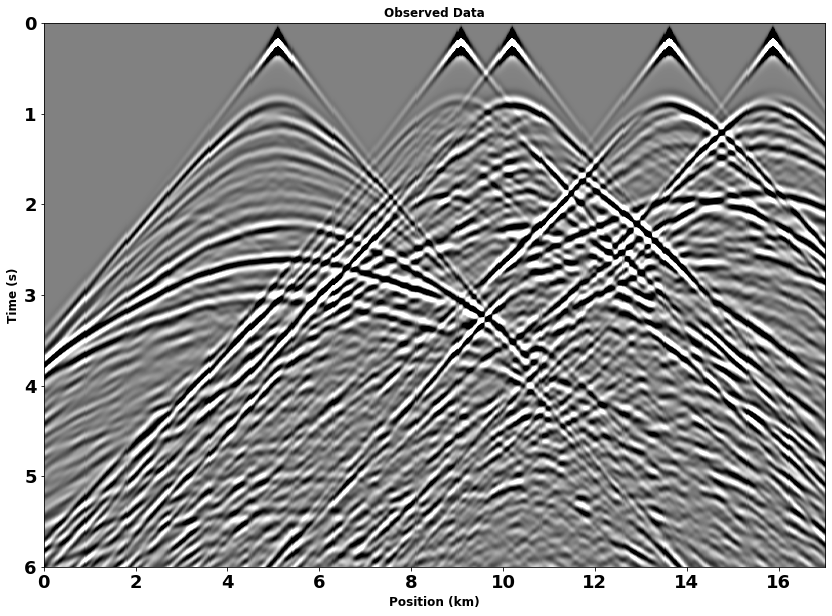

In [9]:
#plt.imshow(batch_rcv_amps_true[:,0,:].detach().cpu().numpy(),aspect='auto',cmap='gray')
#batch_rcv_amps_true[:,0,:].shape


%matplotlib inline 
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}
f, ax = plt.subplots(1, 1, figsize=(14, 10), sharey=False)
plt.rc('font', **font)

selected_shot = rcv_amps_true[:,0,:]
vmin, vmax = torch.quantile(selected_shot,
                            torch.tensor([0.05, 0.95]).to(device))

ax.imshow(selected_shot.cpu(), aspect='auto', cmap='gray',
             vmin=vmin, vmax=vmax,
             extent=[0, selected_shot.shape[1] * dx/1000, selected_shot.shape[0] *(0.003), 0])

ax.set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax.set_ylabel('Time (s)',fontsize='large', fontweight='bold')
ax.set_title('Observed Data',fontsize='large', fontweight='bold')
#ax.text(0, -0.15, 'a)', fontsize = 12) 
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
#ax.set_xticklabels([])
plt.show()
#f.savefig('Observed_Combined.png', bbox_inches='tight',transparent=True, dpi =100)


## Plotting the Reconstructed Velocity Model

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


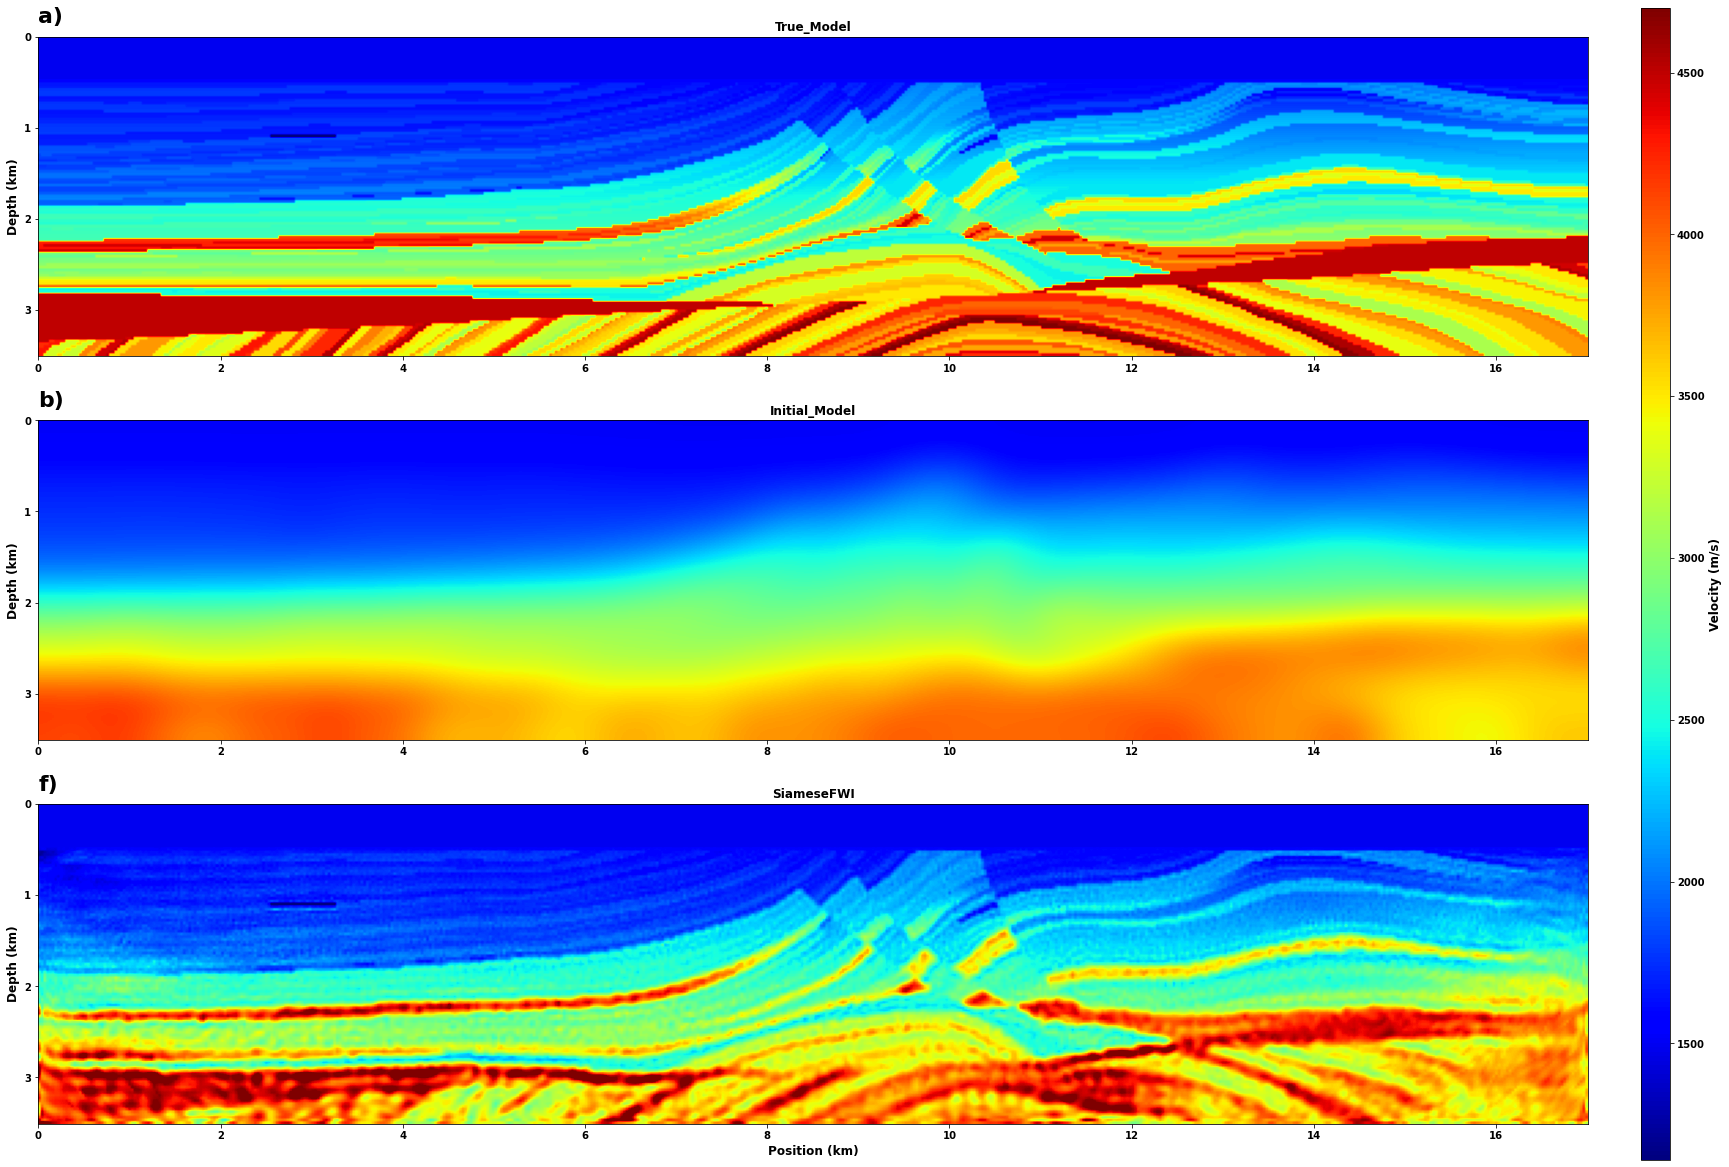

The reconstructed velocity model has SNR: 20.27180284255102 dB and SSIM: 0.6863136


In [10]:
f, ax = plt.subplots(3,1,figsize=(40, 20))
plt.rc('font', **font)

# True Model
modeltrue = model1
im = ax[0].imshow(modeltrue, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, modeltrue.shape[1] * dx / 1000, modeltrue.shape[0] * dx / 1000, 0])

#ax[0].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[0].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[0].set_title('True_Model',fontsize='large', fontweight='bold')
ax[0].text(0, -0.15, 'a)', fontsize = 22) 
ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[0].set_yticks(np.arange(y.min(), y.max(), 1)) 

# Initial Model
init_V = model_init
im = ax[1].imshow(init_V, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, init_V.shape[1] * dx / 1000, init_V.shape[0] * dx / 1000, 0])
#ax[1].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[1].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[1].set_title('Initial_Model',fontsize='large', fontweight='bold')
ax[1].text(0, -0.15, 'b)', fontsize = 22) 
ax[1].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[1].set_yticks(np.arange(y.min(), y.max(), 1)) 

# Siamese Model
Siamese_Vel = scipy.io.loadmat(fwi_result + 'SIAMESERec_.mat')
Siamese_Vel = Siamese_Vel['rec']
im = ax[2].imshow(Siamese_Vel, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, Siamese_Vel.shape[1] * dx / 1000, Siamese_Vel.shape[0] * dx / 1000, 0])
ax[2].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[2].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[2].set_title('SiameseFWI',fontsize='large', fontweight='bold')
ax[2].text(0, -0.15, 'f)', fontsize = 22) 
ax[2].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[2].set_yticks(np.arange(y.min(), y.max(), 1)) 


cbar_ax = f.add_axes([0.8, 0.1, 0.01, 0.8])
f.colorbar(im, fraction=0.005, pad=0.04,cax=cbar_ax)
cbar_ax.set_ylabel('Velocity (m/s)',fontsize='large', fontweight='bold')

plt.show()
f.savefig('FreqFWI_Siamese.png', bbox_inches='tight',transparent=True, dpi =100)

snr = ComputeSNR(Siamese_Vel,  
          model_true.detach().cpu().numpy())

ssim = ComputeSSIM(Siamese_Vel, \
          model_true.detach().cpu().numpy())

print('The reconstructed velocity model has SNR:', str(snr), 'dB', 'and SSIM:',str(ssim.cpu().detach().cpu().numpy()))

## Plotting Velocities Profiles

@Position =  3.6 km, RMSE =  0.22474806277094714 km/s
@Position =  7.2 km, RMSE =  0.20314261470125697 km/s
@Position =  14.4 km, RMSE =  0.19114003839639002 km/s


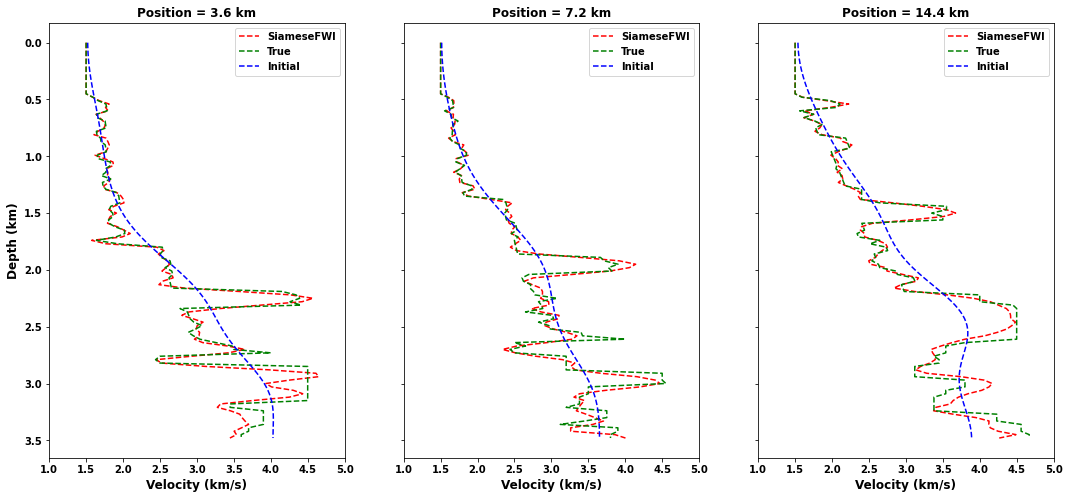

In [11]:
from math import sqrt
# position 1
k = 120

xy = np.arange(0,Siamese_Vel.shape[0] * dx / 1000, len(Siamese_Vel[:,k])/Siamese_Vel.shape[0] * dx / 1000)
f, ax = plt.subplots(figsize=(18, 8), ncols=3,nrows=1)
xx = np.arange(0,4)
ax[0].plot(Siamese_Vel[:,k]/1000,xy,'r--',label='SiameseFWI')
ax[0].plot(modeltrue[:,k]/1000,xy,'g--',label='True')
ax[0].plot(init_V[:,k]/1000,xy,'b--',label='Initial')
ax[0].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[0].set_xlabel('Velocity (km/s)',fontsize='large', fontweight='bold')
ax[0].set_xlim([1,5])
ax[0].legend(loc='upper right')
ax[0].set_title( 'Position = ' + str(k * dx / 1000) +' km',fontsize='large', fontweight='bold')
ax[0].invert_yaxis()
rms = sqrt(np.mean(((modeltrue[:,k]-Siamese_Vel[:,k])/1000)**2))
print('@Position = ', str(k * dx / 1000), 'km, RMSE = ',str(rms), 'km/s')

# position 2
k = 240
xy = np.arange(0,Siamese_Vel.shape[0] * dx / 1000, len(Siamese_Vel[:,k])/Siamese_Vel.shape[0] * dx / 1000)
xx = np.arange(0,4)
ax[1].plot(Siamese_Vel[:,k]/1000,xy,'r--',label='SiameseFWI')
ax[1].plot(modeltrue[:,k]/1000,xy,'g--',label='True')
ax[1].plot(init_V[:,k]/1000,xy,'b--',label='Initial')
ax[1].set_xlabel('Velocity (km/s)',fontsize='large', fontweight='bold')
ax[1].set_yticklabels([])
ax[1].set_xlim([1,5])
ax[1].legend(loc='upper right')
ax[1].set_title( 'Position = ' + str(k * dx / 1000) +' km',fontsize='large', fontweight='bold')
ax[1].invert_yaxis()
rms = sqrt(np.mean(((modeltrue[:,k]-Siamese_Vel[:,k])/1000)**2))
print('@Position = ', str(k * dx / 1000), 'km, RMSE = ',str(rms), 'km/s')

# position 3
k = 480
xy = np.arange(0,Siamese_Vel.shape[0] * dx / 1000, len(Siamese_Vel[:,k])/Siamese_Vel.shape[0] * dx / 1000)
xx = np.arange(0,4)
ax[2].plot(Siamese_Vel[:,k]/1000,xy,'r--',label='SiameseFWI')
ax[2].plot(modeltrue[:,k]/1000,xy,'g--',label='True')
#ax[2].plot(FWIGAN_Vel[:,k]/1000,xy,'y--',label='FWIGAN')
ax[2].plot(init_V[:,k]/1000,xy,'b--',label='Initial')
ax[2].set_xlabel('Velocity (km/s)',fontsize='large', fontweight='bold')
ax[2].set_yticklabels([])
ax[2].set_xlim([1,5])
#ax[2].ylim([0,3.8])
ax[2].legend(loc='upper right')
ax[2].set_title( 'Position = ' + str(k * dx / 1000) +' km',fontsize='large', fontweight='bold')
ax[2].invert_yaxis()
rms = sqrt(np.mean(((modeltrue[:,k]-Siamese_Vel[:,k])/1000)**2))
print('@Position = ', str(k * dx / 1000), 'km, RMSE = ',str(rms), 'km/s')

